In [2]:
# Pytorch
import torch

# ScikitLearn
from sklearn.preprocessing import MinMaxScaler, minmax_scale, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV, learning_curve

# Matplotlib
import matplotlib.pyplot as plt

# Extra utils
import pandas as pd
import numpy as np
import random
import joblib

In [3]:
def set_seed_strict(seed=42):
    # 1. Standard Library Seeds
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # 2. GPU Seeds
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

In [4]:

seed = 42
set_seed_strict(seed)

In [6]:
train_df = pd.read_csv('keypoint_train_data.csv')
valid_df = pd.read_csv('keypoint_valid_data.csv')
test_df = pd.read_csv('keypoint_test_data.csv')

In [7]:
def minmax_normalise(df, variations: str, scaler=None, is_train: bool=True):

    df_normalized = df.copy()

    coord_cols = df_normalized.columns.drop(['image_id', 'cat_id'])

    ####################################
    # Generated from Gemini
    ####################################
    visibility_cols = [col for col in coord_cols if col.endswith('_v')]
    xy_cols = [col for col in coord_cols if not col.endswith('_v')]
    ####################################
    # End
    ####################################

    for visibility_col in visibility_cols:
        col_name = visibility_col.replace('_v', '')
        X_col = f"{col_name}_x"
        y_col = f"{col_name}_y"

        mask = df_normalized[visibility_col] == 0.0
        df_normalized.loc[mask, [X_col, y_col]] = np.nan

    if variations=="col_wise":
        print("Using MinMaxScaler")
        if is_train:
            scaler = MinMaxScaler()
            df_normalized[xy_cols] = scaler.fit_transform(df_normalized[xy_cols])

        else:
            if scaler is None:
                print("No scaler given!")

            df_normalized[xy_cols] = scaler.transform(df_normalized[xy_cols])

    elif variations=="row_wise":
        print("Using minmax_scale")
        scaled_array = minmax_scale(df_normalized[xy_cols], axis=1)
        df_normalized[xy_cols] = scaled_array

    df_normalized[xy_cols] = df_normalized[xy_cols].fillna(0.0)

    if variations=="col_wise" and is_train:
        return df_normalized, scaler
    else:
        return df_normalized

In [8]:
def manual_normalisation(df):
    df_normalized = df.copy()
    coord_cols = df_normalized.columns.drop(['image_id', 'cat_id'])

    for index, row in df_normalized.iterrows():

        raw_coords = row[coord_cols].values.astype(np.float32)

        tensor_coords = torch.tensor(raw_coords).view(17, 3)

        normalized_tensor = normalize_coco_posture_safe(tensor_coords)

        flat_normalized_coords = normalized_tensor.view(-1).numpy()

        df_normalized.loc[index, coord_cols] = flat_normalized_coords

    return df_normalized

def normalize_coco_posture_safe(pos_tensor):

    coords = pos_tensor[:, :2].clone()
    vis = pos_tensor[:, 2].clone()

    valid_mask = vis > 0.0

    if not valid_mask.any():
        return pos_tensor

    l_hip_valid = valid_mask[11].item()
    r_hip_valid = valid_mask[12].item()

    if l_hip_valid and r_hip_valid:
        root = (coords[11] + coords[12]) / 2.0
    elif l_hip_valid:
        root = coords[11]
    elif r_hip_valid:
        root = coords[12]
    else:
        l_sho_valid = valid_mask[5].item()
        r_sho_valid = valid_mask[6].item()
        if l_sho_valid and r_sho_valid:
            root = (coords[5] + coords[6]) / 2.0
        else:
            root = torch.tensor([0.0, 0.0], device=coords.device)

    coords[valid_mask] = coords[valid_mask] - root

    min_vals = coords[valid_mask].min(dim=0)[0]
    max_vals = coords[valid_mask].max(dim=0)[0]
    ranges = max_vals - min_vals
    global_scale = ranges.max()

    coords[valid_mask] = coords[valid_mask] / (global_scale + 1e-6)

    final_tensor = torch.cat([coords, vis.unsqueeze(1)], dim=1)

    return final_tensor

In [9]:
def normalise(df, is_train:bool, type: str=None, scaler=None, variation: str=None):
    if type == "manual":
        df_normalized = manual_normalisation(df)
        return df_normalized

    elif type == "auto" and variation in ["row_wise", "col_wise"]:

        if is_train and variation == "col_wise":
            df_normalized, scaler = minmax_normalise(df=df, variations=variation, scaler=scaler, is_train=is_train)
            return df_normalized, scaler

        else:
            df_normalized = minmax_normalise(df=df, variations=variation, scaler=scaler, is_train=is_train)
            return df_normalized

    else:
        print("Unknown type or variation given.")
        raise ValueError("Normalization failed due to invalid arguments.")

In [10]:
"""
train_df_norm = normalise(train_df, is_train=True, type="auto", variation="col_wise")
validate_df_norm = normalise(valid_df, is_train=True, type="auto", variation="col_wise")
test_df_norm = normalise(test_df, is_train=True, type="auto", variation="col_wise")
"""


train_df_norm = normalise(train_df, is_train=False, type="manual")
validate_df_norm = normalise(valid_df, is_train=False, type="manual")
test_df_norm = normalise(test_df, is_train=False, type="manual")

In [11]:
def convert_Dataframe(df):
    if type(df) == tuple:
        df = df[0]
    return df

In [12]:
train_df_norm = convert_Dataframe(train_df_norm)
validate_df_norm = convert_Dataframe(validate_df_norm)
test_df_norm = convert_Dataframe(test_df_norm)

In [13]:
train_df_norm['cat_id'] = train_df_norm['cat_id'] - 1
validate_df_norm['cat_id'] = validate_df_norm['cat_id'] - 1
test_df_norm['cat_id'] = test_df_norm['cat_id'] - 1

In [14]:
X_train = train_df_norm.drop(['image_id','cat_id'], axis=1)
y_train = train_df_norm['cat_id']

X_valid = validate_df_norm.drop(['image_id','cat_id'], axis=1)
y_valid = validate_df_norm['cat_id']

X_test = test_df_norm.drop(['image_id','cat_id'], axis=1)
y_test = test_df_norm['cat_id']

In [15]:
X_train_full = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)

In [16]:

param_grid = {
    'C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
}

grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf', random_state=42), 
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=None
)

In [17]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [18]:
print(f"Best Hyperparameters Found: {grid_search.best_params_}\n")

print("--- Test Set Classification Report ---")
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

model_filename = 'best_svc_posture_model.pkl'
joblib.dump(best_model, model_filename)
print(f"Model successfully saved to {model_filename}\n")

Best Hyperparameters Found: {'C': 7.0, 'gamma': 0.1}

--- Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.76      0.78        41
           1       0.80      0.83      0.82        48

    accuracy                           0.80        89
   macro avg       0.80      0.79      0.80        89
weighted avg       0.80      0.80      0.80        89

Model successfully saved to best_svc_posture_model.pkl



Generating Learning Curve...


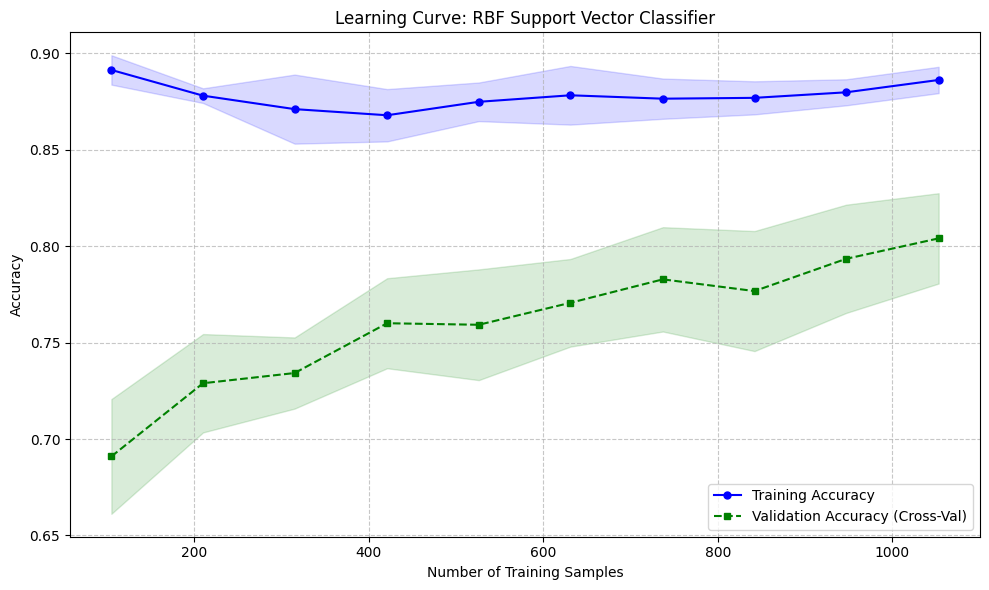

In [19]:
print("Generating Learning Curve...")

# Calculate learning curve scores
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), # Test from 10% of data up to 100%
    cv=5,
    n_jobs=None,
    scoring='accuracy'
)

# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training Accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation Accuracy (Cross-Val)')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

plt.title('Learning Curve: RBF Support Vector Classifier')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
"""
model = SVC(C=6.0, kernel='rbf', gamma='scale', random_state=42)

# Put the training set inside
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)


# Evaluate the model
print(f"\nSVC Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n Normalisation: minmax_scale")
print("\nClassification Report for SVC:\n")
print(classification_report(y_test, y_pred))

# Calculate training accuracy
y_train_pred_svc = model.predict(X_train)
train_accuracy_svc = accuracy_score(y_train, y_train_pred_svc)

# Calculate validation accuracy
y_valid_pred_svc = model.predict(X_valid)
valid_accuracy_svc = accuracy_score(y_valid, y_valid_pred_svc)

# Train, Valid, Test accuracy
test_accuracy_svc = accuracy_score(y_test, y_pred)

print(f"SVC Training Accuracy: {train_accuracy_svc:.4f}")
print(f"SVC Validation Accuracy: {valid_accuracy_svc:.4f}")
print(f"SVC Test Accuracy: {test_accuracy_svc:.4f}")

# Test a range
for C in [0.3 , 0.2, 0.1, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]:
    model = SVC(C=C, kernel='rbf', gamma='scale')
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc

    print(f"C={C}: Train={train_acc:.4f}, Test={test_acc:.4f}, Gap={gap:.4f}")
"""